# HW13: Tokenization, BERT inference, fine-tuning

Датасет: `emotion` (HuggingFace Datasets).

Что есть в ноутбуке:
- sanity-check данных;
- токенизация и special tokens;
- инференс готовой модели;
- fine-tuning для sequence classification;
- итоговая оценка на test и сохранение артефактов.


In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cpu


## 1) Данные и sanity-check


In [2]:
ds = load_dataset('emotion')
label_names = ds['train'].features['label'].names
num_labels = len(label_names)
id2label = {i: n for i, n in enumerate(label_names)}
label2id = {n: i for i, n in enumerate(label_names)}

print('Splits:', {k: len(v) for k, v in ds.items()})
print('Classes:', label_names)

pd.DataFrame({
    'text': ds['train']['text'][:5],
    'label_id': ds['train']['label'][:5],
    'label_name': [label_names[i] for i in ds['train']['label'][:5]]
})


Splits: {'train': 16000, 'validation': 2000, 'test': 2000}
Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


,text,label_id,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


## 2) Токенизация


In [3]:
model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

examples = ds['train']['text'][:3]
for i, t in enumerate(examples, 1):
    tokens = tokenizer.tokenize(t)
    encoded = tokenizer(t, truncation=True, max_length=32)
    print(f'--- Example {i} ---')
    print('TEXT:', t[:140])
    print('TOKENS:', tokens[:20])
    print('input_ids:', encoded['input_ids'][:20])
    print('attention_mask:', encoded['attention_mask'][:20])

batch_demo = tokenizer(examples, padding=True, truncation=True, max_length=32, return_tensors='pt')
print('Special tokens:', tokenizer.special_tokens_map)
print('Batch input_ids shape:', tuple(batch_demo['input_ids'].shape))
print('Batch attention_mask shape:', tuple(batch_demo['attention_mask'].shape))


--- Example 1 ---
TEXT: i didnt feel humiliated
TOKENS: ['i', 'didn', '##t', 'feel', 'humiliated']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1]
--- Example 2 ---
TEXT: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
TOKENS: ['i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
--- Example 3 ---
TEXT: im grabbing a minute to post i feel greedy wrong
TOKENS: ['im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong']
input_ids: [101, 10047, 9775, 1037, 3371, 2000, 2695, 1045, 2514, 20505, 3308, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

## 3) Инференс готовой pretrained модели


In [4]:
ready_pipe = pipeline(
    'text-classification',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=0 if torch.cuda.is_available() else -1,
)

demo_texts = [
    'I am very happy today and everything is awesome.',
    'I feel scared and nervous about tomorrow.',
    'This situation makes me so angry right now.',
]

ready_preds = ready_pipe(demo_texts)
pd.DataFrame({'text': demo_texts, 'pretrained_prediction': ready_preds})


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,text,pretrained_prediction
0,I am very happy today and everything is awesome.,"{'label': 'POSITIVE', 'score': 0.9998773336410..."
1,I feel scared and nervous about tomorrow.,"{'label': 'NEGATIVE', 'score': 0.9894039630889..."
2,This situation makes me so angry right now.,"{'label': 'NEGATIVE', 'score': 0.9985436201095..."


## 4) Fine-tuning на emotion


In [5]:
def preprocess(batch):
    return tokenizer(batch['text'], truncation=True, max_length=128)

tokenized = ds.map(preprocess, batched=True)
tokenized = tokenized.rename_column('label', 'labels')
tokenized = tokenized.remove_columns(['text'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
common_kwargs = dict(
    output_dir='./_trainer_output',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    max_steps=500 if not torch.cuda.is_available() else 900,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=1,
    report_to='none',
    seed=42,
    eval_steps=100,
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
)

try:
    training_args = TrainingArguments(evaluation_strategy='steps', save_strategy='steps', **common_kwargs)
except TypeError:
    training_args = TrainingArguments(eval_strategy='steps', save_strategy='steps', **common_kwargs)

try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized['train'],
        eval_dataset=tokenized['validation'],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized['train'],
        eval_dataset=tokenized['validation'],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result


c:\Users\Maken\Desktop\AI-course\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss,Accuracy,F1 Macro
100,1.403261,1.282937,0.542000,0.226219
200,0.984349,0.939247,0.706500,0.467568
300,0.848168,0.778008,0.750000,0.534596
400,0.638416,0.663797,0.776500,0.561605
500,0.695664,0.635082,0.783500,0.572115


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Maken\Desktop\AI-course\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Maken\Desktop\AI-course\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=500, training_loss=0.9756649856567383, metrics={'train_runtime': 707.8288, 'train_samples_per_second': 5.651, 'train_steps_per_second': 0.706, 'total_flos': 42754832782560.0, 'train_loss': 0.9756649856567383, 'epoch': 0.25})

## 5) Оценка на test и артефакты


c:\Users\Maken\Desktop\AI-course\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


test_accuracy = 0.8115
test_f1_macro = 0.593


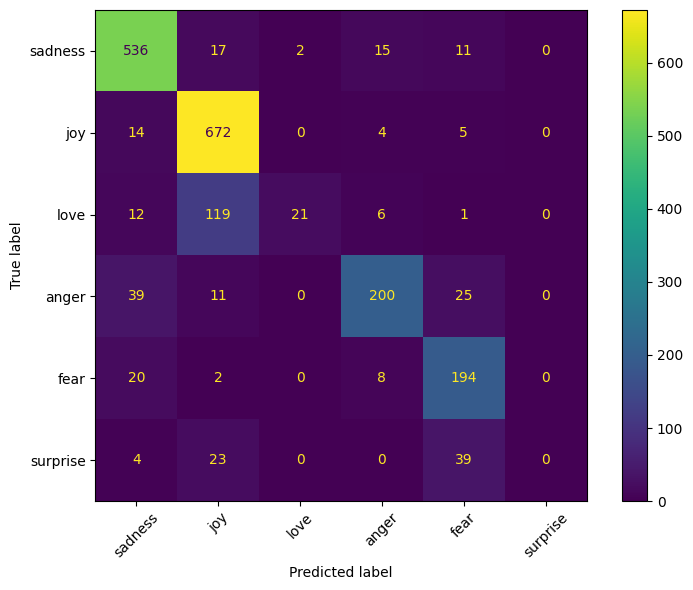

,text,true_label,pred_label,confidence
0,i feel impatient i just post a blog entry and ...,anger,anger,0.522702
1,im not sure why but im just feeling delicate,love,joy,0.413660
2,i had a fab christmas and an amazing new year ...,joy,joy,0.874016
3,im feeling very disturbed by tons of things,sadness,fear,0.591747
4,i feel as though i am on another adventure and...,surprise,fear,0.374653
5,i feel betrayed and angry and sad at the same ...,anger,sadness,0.789963
6,i miss not feeling exhausted after being outsi...,sadness,sadness,0.837727
7,i feel kinda weird when andrea tries to talk t...,fear,fear,0.678818
8,i purple month doesnt feel surprised in fact z...,surprise,joy,0.289671
9,im feeling a little lethargic,sadness,sadness,0.700621


In [7]:
artifacts_dir = Path('./artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

test_pred = trainer.predict(tokenized['test'])
y_true = test_pred.label_ids
y_pred = np.argmax(test_pred.predictions, axis=-1)

test_accuracy = accuracy_score(y_true, y_pred)
test_f1_macro = f1_score(y_true, y_pred, average='macro')
print('test_accuracy =', round(test_accuracy, 4))
print('test_f1_macro =', round(test_f1_macro, 4))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, xticks_rotation=45)
plt.tight_layout()
plt.savefig(artifacts_dir / 'confusion_matrix.png', dpi=150)
plt.show()

probs = torch.softmax(torch.tensor(test_pred.predictions), dim=-1).numpy()
conf = probs.max(axis=1)

sample_idx = np.random.default_rng(42).choice(len(y_true), size=10, replace=False)
sample_df = pd.DataFrame({
    'text': [ds['test'][int(i)]['text'] for i in sample_idx],
    'true_label': [label_names[int(y_true[i])] for i in sample_idx],
    'pred_label': [label_names[int(y_pred[i])] for i in sample_idx],
    'confidence': [float(conf[i]) for i in sample_idx],
})
sample_df.to_csv(artifacts_dir / 'sample_predictions.csv', index=False)
sample_df
